# <div style="text-align: center;">*CAR  PRICE  PREDICTION.*</div>

# PHASE 1 - EDA.

- # DATA EXPLORATION.

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load the dataset

df = pd.read_csv('../datasets/car data.csv')

In [4]:
# explore the dataset

print('                                                   TOP 5 ROWS OF THE DATASET\n'                               )
print(df.head())
print('\n                                                   BOTTOM 5 ROWS OF THE DATASET\n'                               )
print(df.tail())
print('\n                                                   DATASET INFORMATION\n'                               )
print(df.info())
print('\n                                                   DATASET DESCRIPTION\n'                               )
print(df.describe())
print('\n                                                   DATASET SHAPE\n'                               )
print(df.shape)





                                                   TOP 5 ROWS OF THE DATASET

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

                                                   BOTTOM 5 ROWS OF THE DATASET

    Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
296     city  2016           9.50           11.6       33988    Diesel   
297     brio  2015           4.00    

# key insights from the above exploration are:
- The dataset contains 301 rows and 9 columns.
- The dataset contains both numerical and categorical features.
- The target variable is 'Selling_Price', which is a numerical feature.




In [5]:
# check for missing values and duplicates in the dataset.

print('\n                                                   MISSING VALUES IN THE DATASET\n'                               )
print(df.isnull().sum())
print('\n                                                   DUPLICATE VALUES IN THE DATASET\n'                               )
print('Duplicated Values:',df.duplicated().sum())
duplicates = df[df.duplicated(keep=False)]
print("Duplicate rows:")
print(duplicates)
print('\n                                                   AFTER REMOVING DUPLICATES VALUES\n'                               )
print(df.drop_duplicates(inplace=True))
print('Duplicated values after removing duplicates:',df.duplicated().sum())





                                                   MISSING VALUES IN THE DATASET

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

                                                   DUPLICATE VALUES IN THE DATASET



Duplicated Values: 2
Duplicate rows:
    Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
15    ertiga  2016           7.75          10.79       43000    Diesel   
17    ertiga  2016           7.75          10.79       43000    Diesel   
51  fortuner  2015          23.00          30.61       40000    Diesel   
93  fortuner  2015          23.00          30.61       40000    Diesel   

   Selling_type Transmission  Owner  
15       Dealer       Manual      0  
17       Dealer       Manual      0  
51       Dealer    Automatic      0  
93       Dealer    Automatic      0  

                                                   AFTER REMOVING DUPLICATES VALUES

None
Duplicated values after removing duplicates: 0


# key insights from the above exploration are:

- There are no missing values in the dataset.
- There are 2 duplicate rows in the dataset, which have been removed.


In [6]:
# let's get the value counts of the categorical features in the dataset.

print('\n                                                   VALUE COUNTS OF THE CATEGORICAL FEATURES\n'                               )
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
print('Value counts of Fuel_Type:\n',df['Fuel_Type'].value_counts())
print('\nValue counts of Seller_Type:\n',df['Selling_type'].value_counts())
print('\nValue counts of Transmission:\n',df['Transmission'].value_counts())


                                                   VALUE COUNTS OF THE CATEGORICAL FEATURES

Value counts of Fuel_Type:
 Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Value counts of Seller_Type:
 Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

Value counts of Transmission:
 Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [7]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [8]:
# let's extarct the 'Year' column from the dataset and create a new column called 'Car_Age' which will represent the age of the car.

print('\n                                                   CAR AGE COLUMN\n'                               )
df['Car_Age'] = 2026 - df['Year']
print(df[['Year', 'Car_Age']].head(10))



                                                   CAR AGE COLUMN

   Year  Car_Age
0  2014       12
1  2013       13
2  2017        9
3  2011       15
4  2014       12
5  2018        8
6  2015       11
7  2015       11
8  2016       10
9  2015       11


In [9]:
# now let's drop the 'Year' column from the dataset.

df.drop('Year', axis=1, inplace=True)

# DATA VISUALIZATION.

ValueError: num must be an integer with 1 <= num <= 3, not 4

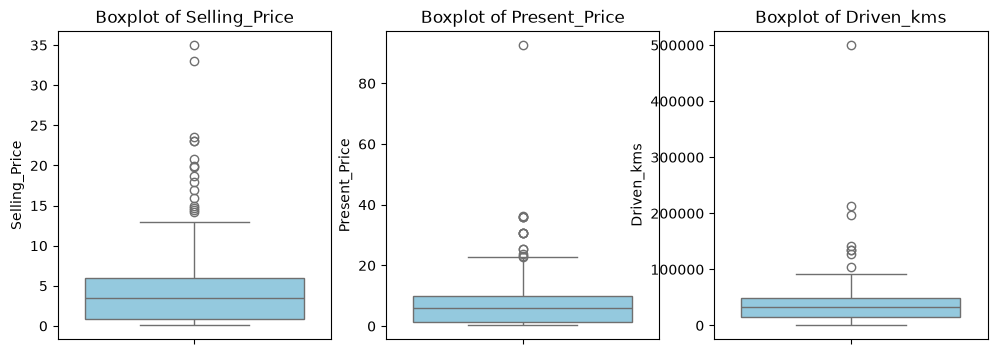

In [13]:
# let's check for any outliers in the dataset using boxplots.

num_cols = ['Selling_Price', 'Present_Price', 'Driven_kms', 'Car_Age']
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()